In [ ]:
import polars as pl

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### 設問1

In [ ]:
df1=pl.read_csv("/content/drive/MyDrive/最終課題/総合課題データ/総合課題データ/store/201101.csv")

In [ ]:
df2=pl.read_csv("/content/drive/MyDrive/最終課題/総合課題データ/総合課題データ/store/201102.csv")

In [ ]:
df3=pl.read_csv("/content/drive/MyDrive/最終課題/総合課題データ/総合課題データ/store/201103.csv")

In [ ]:
df4=pl.read_csv("/content/drive/MyDrive/最終課題/総合課題データ/総合課題データ/store/201104.csv")

In [ ]:
df5=pl.read_csv("/content/drive/MyDrive/最終課題/総合課題データ/総合課題データ/store/201105.csv")

In [ ]:
df6=pl.read_csv("/content/drive/MyDrive/最終課題/総合課題データ/総合課題データ/store/201106.csv")

In [ ]:
df12=pl.concat([df1,df2])

In [ ]:
df123=pl.concat([df12,df3])

In [ ]:
df1234=pl.concat([df123,df4])

In [ ]:
df12345=pl.concat([df1234,df5])

In [ ]:
df=pl.concat([df12345,df6])

In [ ]:
x1=df.select(pl.col(["顧客","金額"]))

In [ ]:
top5=x1.sort("金額",  descending=True).head(5)

In [ ]:
print(top5)

shape: (5, 2)
┌──────────┬────────┐
│ 顧客     ┆ 金額   │
│ ---      ┆ ---    │
│ str      ┆ i64    │
╞══════════╪════════╡
│ null     ┆ 620700 │
│ 10011037 ┆ 542800 │
│ null     ┆ 440330 │
│ null     ┆ 437600 │
│ null     ┆ 424100 │
└──────────┴────────┘


In [ ]:
top5.write_csv("/content/drive/MyDrive/最終課題/総合課題１.csv")

#### 設問2

In [ ]:
s2=df.filter(~pl.col("デプト").is_null())

In [ ]:
ss2=s2.group_by("デプト").agg(pl.col("数量").sum())

In [ ]:
top52=ss2.sort("数量",  descending=True).head(5)

In [ ]:
print(top52)

shape: (5, 2)
┌────────┬────────┐
│ デプト ┆ 数量   │
│ ---    ┆ ---    │
│ i64    ┆ i64    │
╞════════╪════════╡
│ 180    ┆ 838946 │
│ 30     ┆ 734379 │
│ 120    ┆ 703763 │
│ 130    ┆ 679149 │
│ 160    ┆ 356903 │
└────────┴────────┘


In [ ]:
top52.write_csv("/content/drive/MyDrive/最終課題/総合課題２.csv")

#### 設問3

In [ ]:
display(df)

店,日付,レジ,レシート,時間,顧客,部門,グループ,デプト,クラス,商品,商品名,数量,金額
i64,i64,i64,i64,i64,str,i64,i64,i64,i64,i64,str,i64,i64
390,20110109,101,9142,114700,null,2,27,730,4436,4902112041048,"""ミオおいしい毛玉対応まぐろ２．５ＫＧ""",1,399
390,20110111,110,8672,94900,null,1,11,120,1240,4903001903317,"""ヤマサ_鮮度の一滴特選しょうゆ５００ＭＬ""",1,268
390,20110111,106,1224,100400,null,1,11,80,2349,4901870600610,"""ＣＧＣ_森林そだち_大玉（１０個）""",1,99
390,20110111,106,1225,100500,null,1,11,80,2349,4901870600627,"""ＣＧＣ_森林そだち_中玉（１０個）""",2,178
390,20110111,106,1227,100700,null,1,11,120,1207,4901777206724,"""サントリー_アセロラリフレッシュ５００""",1,89
…,…,…,…,…,…,…,…,…,…,…,…,…,…
390,20110609,107,7325,94700,null,1,14,160,2851,2264,"""イカフライばら""",0,0
390,20110610,101,5785,92200,null,1,13,150,1782,220495000006,"""本まぐろ刺身平造り・大・解凍""",0,0
390,20110609,107,7325,94700,null,1,14,160,2854,2103,"""いか天ぷら（ばら）""",0,0


In [ ]:
s3 = pl.DataFrame({ "月": [1, 2, 3, 4, 5, 6]})


In [ ]:
s31=df1.select(pl.col("金額").sum())

In [ ]:
ss2=df2.select(pl.col("金額").sum())

In [ ]:
ss3=df3.select(pl.col("金額").sum())

In [ ]:
ss4=df4.select(pl.col("金額").sum())

In [ ]:
ss5=df5.select(pl.col("金額").sum())

In [ ]:
ss6=df6.select(pl.col("金額").sum())

In [ ]:
ss12=pl.concat([s31,ss2])

In [ ]:
ss123=pl.concat([ss12,ss3])

In [ ]:
ss1234=pl.concat([ss123,ss4])

In [ ]:
ss12345=pl.concat([ss1234,ss5])

In [ ]:
ss123456=pl.concat([ss12345,ss6])

In [ ]:
display(ss123456)

金額
i64
256345920
153066313
302925233
231053394
244304767
302576367


In [ ]:
ssmonth = ss123456.with_row_index("月").with_columns(
    (pl.col("月") + 1).alias("月")
)

In [ ]:
ssmonth.write_csv("/content/drive/MyDrive/最終課題/総合課題3.csv")

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
!pip install japanize-matplotlib
import japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 51.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=26f5a0b10232add12de8fd9f916e24d3f6c5062a6e3a49545799df2231300279
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


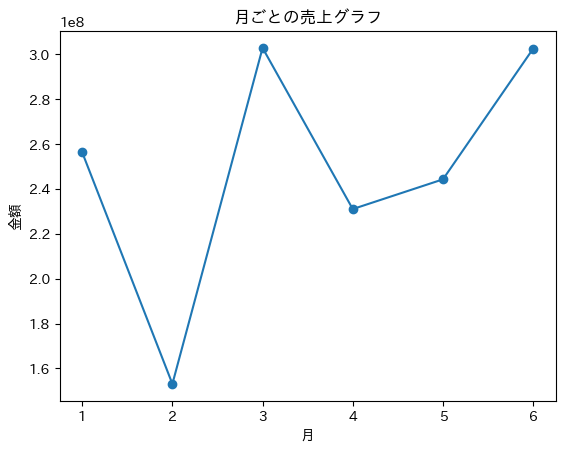

In [ ]:
plt.plot(ssmonth["月"],ssmonth["金額"], marker ="o")
plt.title("月ごとの売上グラフ")
plt.xlabel("月")
plt.ylabel("金額")
plt.savefig("/content/drive/MyDrive/最終課題/総合課題3.png")


#### 設問4

In [ ]:
cust=pl.read_csv("/content/drive/MyDrive/最終課題/総合課題データ/総合課題データ/Master/customer.csv")

In [ ]:
display(cust)

顧客,性別,生年月日
str,str,i64
"""NA""","""未回答""",null
"""10000002""","""男性""",19510707
"""10000003""","""男性""",19541224
"""10000004""","""女性""",19570815
"""10000005""","""男性""",19831027
…,…,…
"""10515392""","""女性""",19730425
"""10515393""","""男性""",19610430
"""10900000""","""未回答""",null


In [ ]:
df_buy = df.with_columns(pl.col("日付").cast(pl.Utf8).str.strptime(pl.Date, "%Y%m%d"))

df_customer = cust.with_columns(
    pl.col("生年月日").cast(pl.Utf8).str.strptime(pl.Date, "%Y%m%d")
)

In [ ]:
s4 = df_buy.join(
    df_customer,
    on="顧客",
    how="left"
)

In [ ]:
display(s4)

店,日付,レジ,レシート,時間,顧客,部門,グループ,デプト,クラス,商品,商品名,数量,金額,性別,生年月日
i64,date,i64,i64,i64,str,i64,i64,i64,i64,i64,str,i64,i64,str,date
390,2011-01-09,101,9142,114700,null,2,27,730,4436,4902112041048,"""ミオおいしい毛玉対応まぐろ２．５ＫＧ""",1,399,null,null
390,2011-01-11,110,8672,94900,null,1,11,120,1240,4903001903317,"""ヤマサ_鮮度の一滴特選しょうゆ５００ＭＬ""",1,268,null,null
390,2011-01-11,106,1224,100400,null,1,11,80,2349,4901870600610,"""ＣＧＣ_森林そだち_大玉（１０個）""",1,99,null,null
390,2011-01-11,106,1225,100500,null,1,11,80,2349,4901870600627,"""ＣＧＣ_森林そだち_中玉（１０個）""",2,178,null,null
390,2011-01-11,106,1227,100700,null,1,11,120,1207,4901777206724,"""サントリー_アセロラリフレッシュ５００""",1,89,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
390,2011-06-09,107,7325,94700,null,1,14,160,2851,2264,"""イカフライばら""",0,0,null,null
390,2011-06-10,101,5785,92200,null,1,13,150,1782,220495000006,"""本まぐろ刺身平造り・大・解凍""",0,0,null,null
390,2011-06-09,107,7325,94700,null,1,14,160,2854,2103,"""いか天ぷら（ばら）""",0,0,null,null


In [ ]:
s4=s4.select(pl.col(["日付","顧客","生年月日"]))

In [ ]:
s4=s4.filter(~pl.col("顧客").is_null())
s4=s4.filter(~pl.col("生年月日").is_null())
s4=s4.filter(~pl.col("日付").is_null())

In [ ]:
s4 = s4.with_columns( ((pl.col("日付") - pl.col("生年月日")).dt.total_days() // 365.25).cast(pl.Int64).alias("年齢"))


In [ ]:
s4_unique = s4.unique(
    subset=["日付", "顧客"],
    keep="first"
)

In [ ]:
display(s4_unique)

日付,顧客,生年月日,年齢
date,str,date,i64
2011-01-29,"""10359562""",1952-11-12,58
2011-05-25,"""10007015""",1971-11-30,39
2011-01-04,"""10002593""",1943-01-08,67
2011-01-05,"""10009184""",1962-07-20,48
2011-02-22,"""10327894""",1976-01-11,35
…,…,…,…
2011-03-03,"""10006869""",1947-09-04,63
2011-05-03,"""10012459""",1931-05-03,80
2011-06-05,"""10014651""",1960-02-01,51


In [ ]:
ss4=s4_unique.group_by("年齢").agg(
    pl.len().alias("来店回数")
)

In [ ]:
ss4=ss4.sort("年齢",descending=True)

In [ ]:
sss4=ss4.sort("来店回数",descending=True).head(5)

In [ ]:
display(sss4)

年齢,来店回数
i64,u32
62,8682
43,8182
63,8138
41,8057
61,7988


In [ ]:
sss4.write_csv("/content/drive/MyDrive/最終課題/総合課題4.csv")

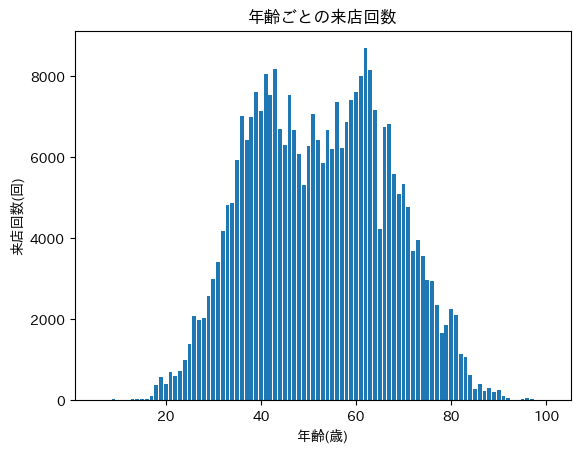

In [ ]:
plt.bar(ss4["年齢"],ss4["来店回数"])
plt.title("年齢ごとの来店回数")
plt.xlabel("年齢(歳)")
plt.ylabel("来店回数(回)")
plt.savefig("/content/drive/MyDrive/最終課題/総合課題4.png")


#### まとめ

①講義の難易度はどうでしたか？

難しい・普通・簡単

②講義の感想を記入してください